# This script runs the Example 1 on OpenTRIM (`opentrim`) from a Python notebook

In this notebook we create the configuration for example 1 and run it through Python.


It assumes `opentrim` is available on your `PATH`. If it is not, set `exe`
to the full path (example in the comment below).

In [17]:
from pathlib import Path   # convenient, cross-platform path handling (files, joining paths, etc.)
import json                # encode/decode JSON (opentrim -t output, writing config.json)

import subprocess          # run the external `opentrim` executable and capture stdout/stderr
import tempfile            # create a temporary directory to run opentrim without polluting your repo

from typing import Any, Dict  # type hints for config dictionaries, helps readability in notebooks

import h5py                # read the HDF5 output file produced by opentrim (result.h5)
import numpy as np         # convert datasets to NumPy arrays, manipulate/flatten/slice for plotting
import matplotlib.pyplot as plt  # plot results from datasets using Matplotlib

The code below generates the template json file.

In [18]:
exe = "opentrim"
cmd_template = [exe, "-t"]

template_run = subprocess.run(
    cmd_template,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    timeout=20,
)

template_run.check_returncode()  # raises if opentrim -t failed
# Start Config from the template
Config: Dict[str, Any] = json.loads(template_run.stdout)



## Customize the Config in the code below:

In [19]:
# Example edits:
Config["Output"]["title"] = "270keV He in 100μm/cm^2 C foil"

Config["Run"]["threads"] = 0
Config["Run"]["max_no_ions"] = 1000000  

Config["Simulation"]["simulation_type"] = "IonsOnly"

Config["Transport"]["flight_path_type"] = "Variable"
Config["Transport"]["min_scattering_angle"] = 0.05

Config["IonBeam"]["ion"] = {
    "symbol": "He",
    "atomic_mass": 4.0026,
    "atomic_number": 2
}
Config["IonBeam"]["energy_distribution"]["center"] = 270000.0
Config["IonBeam"]["spatial_distribution"]["center"] = [
                0.0,
                1000.0,
                1000.0
            ]

Config["Target"]["size"] = [
            440.0,
            2000.0,
            2000.0
        ]
Config["Target"]["cell_count"] = [
            1,
            1,
            1
        ]
Config["Target"]["periodic_bc"] = [
            0,
            1,
            1
        ]

# Materials
Config["Target"]["materials"][0]["id"] = "Carbon foil"
Config["Target"]["materials"][0]["density"] = 2.27
Config["Target"]["materials"][0]["composition"] = [
    {
        "element": {"symbol": "C", "atomic_mass": 12.011},
        "X": 1,
        "Ed": 20,
        "El": 3,
        "Es": 3,
        "Er": 20
    }
]

# Regions
Config["Target"]["regions"][0]["id"] = "R1"
Config["Target"]["regions"][0]["material_id"] = "Carbon foil"
Config["Target"]["regions"][0]["size"] = [
            1000.0,
            10000.0,
            10000.0
        ]

# User tally
Config["UserTally"] = [
    {
        "id": "AngularDistribution",
        "description": "Angular distribution of He ions exiting the foil",
        "event": "IonExit",
        "bins": {
            "nx": [
                0.980, 0.981, 0.982, 0.983, 0.984, 0.985, 0.986,
                0.987, 0.988, 0.989, 0.990, 0.991, 0.992, 0.993,
                0.994, 0.995, 0.996, 0.997, 0.998, 0.999, 1.000
            ],
            "x": [440, 450],
            "atom_id": [0, 1]
        }
    }
]

Running Opentrim and plotting results:

returncode: 0
stdout:
 Parsing JSON config from config.json
Starting simulation '270keV He in 100μm/cm^2 C foil'...


║                                        ║  0%║ETC 00:00:00║
║▊                                       ║  1%║ETC 00:00:10║
║█▋                                      ║  4%║ETC 00:00:10║
║██▍                                     ║  5%║ETC 00:00:10║
║███▎                                    ║  8%║ETC 00:00:09║
║████▏                                   ║ 10%║ETC 00:00:09║
║████▉                                   ║ 12%║ETC 00:00:09║
║█████▋                                  ║ 14%║ETC 00:00:09║
║██████▌                                 ║ 16%║ETC 00:00:09║
║███████▍                                ║ 18%║ETC 00:00:08║
║████████▎                               ║ 20%║ETC 00:00:08║
║█████████                               ║ 22%║ETC 00:00:08║
║█████████▉                              ║ 24%║ETC 00:00:08║
║██████████▋                             ║ 26%║ETC 00:00:08║
║███████████▋               

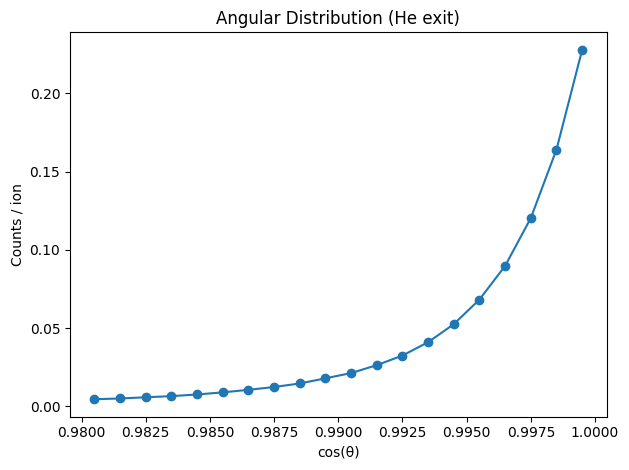

In [20]:
# --- Run opentrim in an isolated temp directory, then read+plot the result ---

with tempfile.TemporaryDirectory(prefix="opentrim_") as tmp:
    tmpdir = Path(tmp)
    h5_path = tmpdir / "result.h5"

    config_path = tmpdir / "config.json"
    config_path.write_text(json.dumps(Config, indent=4) + "\n", encoding="utf-8")

    cmd = [exe, "-f", "config.json", "-o", "result", "-s", "42"]
    result = subprocess.run(
        cmd,
        cwd=str(tmpdir),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        stdin=subprocess.DEVNULL,
        timeout=120,
    )

    print("returncode:", result.returncode)
    print("stdout:\n", result.stdout)
    print("stderr:\n", result.stderr)

    result.check_returncode()

    if not h5_path.exists():
        raise FileNotFoundError(f"Expected output file not found: {h5_path}")

    print("\nOpening:", h5_path)

    with h5py.File(h5_path, "r") as f:
        # Angular distribution tally
        data = np.asarray(f["/user_tally/AngularDistribution/data"][...])  # shape (1, 20, 1)
        theta_bins = np.asarray(f["/user_tally/AngularDistribution/bins/1"][...])  # length 21

        # Convert bins to bin centers for plotting
        theta_centers = 0.5 * (theta_bins[:-1] + theta_bins[1:])  # length 20
        y = data[0, :, 0]  # length 20

        plt.figure()
        plt.plot(theta_centers, y, marker="o")
        plt.xlabel("cos(θ)")
        plt.ylabel("Counts / ion")
        plt.title("Angular Distribution (He exit)")
        plt.tight_layout()
        plt.show()